# Lecture 3: 1D Nonlinear Convection

In this notebook, I solve the one-dimensional nonlinear convection equation using an explicit upwind finite-difference method.

The equation is:

$$
\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} = 0
$$

Unlike linear convection, the convection speed is not constant. The solution itself controls the local wave speed.

In [2]:
import numpy as np  # -> arrays and numerical operations
import matplotlib.pyplot as plt  # -> plotting
from pathlib import Path # -> easier file/folder handling

In [3]:
# Definition of Numerical Grid 

nx = 41 # number of grid points 
length = 2.0 # domain length

dx = length / (nx - 1) # distance between neighboring grid points 
x = np.linspace(0, length, nx)

print("Number of grid points: ", nx)
print("Domain length: ", length)
print("Grid spacing dx: ", dx)
print("First five x values: ", x[:5])

Number of grid points:  41
Domain length:  2.0
Grid spacing dx:  0.05
First five x values:  [0.   0.05 0.1  0.15 0.2 ]


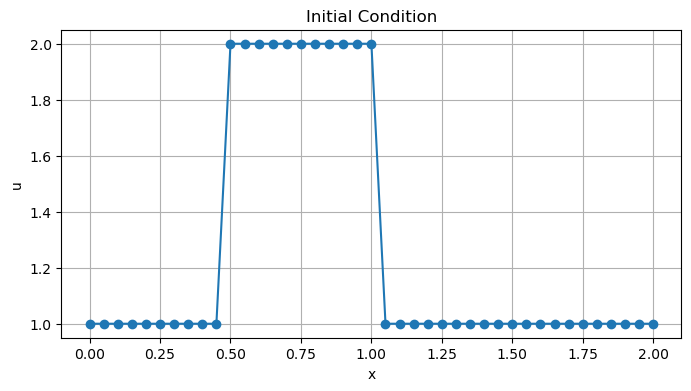

In [5]:
# Defining the initial condition
u_initial = np.ones(nx)
u_initial[int(0.5/dx):int(1.0/dx+1)] = 2

plt.figure(figsize=(8,4))
plt.plot(x, u_initial, marker = "o")
plt.xlabel("x")
plt.ylabel("u")
plt.title("Initial Condition")
plt.grid()
plt.show()

# u = 2 between x = 0.5 and x = 1.0
# u = 1 everywhere else

## Linear and Nonlinear Convection 

In Linear convection, the equation is:

$$
\frac{\partial u}{\partial t} + c \frac{\partial u}{\partial x} = 0
$$

The wave speed is the constant value \(c\)

In nonlinear convection, the equation is:

$$
\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} = 0
$$

The wave speed is the local value of \(u\)
This means regions wth larger  \(u\) move faster than regions with smaller \(u\). Therefore, the shape of the wave can deform over time.


In [7]:
# Linear Convection: wave moves without changing shape.
# Nonlinear Convection: wave moves and changes shape. 

## Finite-Difference Discretization

The nonlinear convection equation is:

$$
\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} = 0
$$

Using a forward difference in time:

$$
\frac{\partial u}{\partial t}
\approx
\frac{u_i^{n+1} - u_i^{n}}{\partial x}
$$

Using a backward difference in space:

$$
\frac{\partial u}{\partial x}
\approx
\frac{u_i^n - u_{i-1}^n}{\Delta x}
$$

Substituting into the equation gives:

$$
u_i^{n+1}
=
u_i^n
-
u_i^n
\frac{\Delta t}{\Delta x}
\left(
u_i^n - u_{i-1}^n
\right)
$$


In [10]:
# The important Python update will be 

# u[i] = un[i] - un[i] * dt/dx * (un[i] - un[i-1])

In [12]:
# Compare it with Lecture 2

# Linear Convection 
# u[i] = un[i] - c * dt/dx * (un[i] - un[i-1])

# Nonlinear Convection 
# u[i] = un[i] - un[i] * dt/dx * (un[i] - un[i-1])

# Basically c becomes un[i]

In [13]:
# Define Simulation Parameters

nt = 20 # number of time steps 
dt = 0.025 # time-step size 

max_u = np.max(u_initial)
cfl = max_u * dt / dx   # for nonlinear convection ; in lienar convection c * dt / dx

print("Number of time steps: ", nt)
print("Time step dt: ", dt)
print("Maximum u:", max_u)
print("CFL Number:", cfl)

Number of time steps:  20
Time step dt:  0.025
Maximum u: 2.0
CFL Number: 1.0


In [ ]:
# Implement Nonlinear Convection Directly 

u = u_initial.copy()

for n in range(nt): # n is time marching
    un = u.copy()  # old solution at the current time step, u is updated solution

    for i in range(1, nx): # i spatial grid update
        u[i] = un[i] - un[i] * dt / dx * (un[i] - un[i-1])

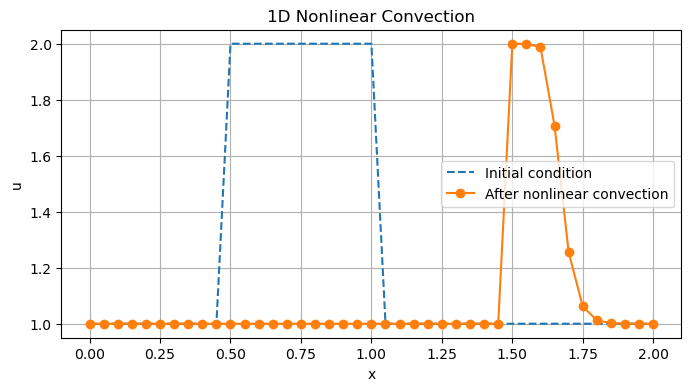

In [16]:
plt.figure(figsize=(8, 4))

plt.plot(x, u_initial, label="Initial condition", linestyle="--")
plt.plot(x, u, label="After nonlinear convection", marker="o")

plt.xlabel("x")
plt.ylabel("u")
plt.title("1D Nonlinear Convection")
plt.legend()
plt.grid()
plt.show()

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def solve_nonlinear_convection(nx=41, nt=20, dt=0.025, length=2.0):
    """
    Solve the 1D nonlinear convection equation using an explicit upwind scheme.
    
    Equation:
        du/dt + u du/dx = 0
    
    Parameters
    ----------
    nx : int
        Number of grid points.
    nt : int
        Number of time steps.
    dt : float
        Time-step size.
    length : float
        Length of the spatial domain.
    
    Returns
    -------
    x : numpy.ndarray
        Spatial grid.
    u_initial : numpy.ndarray
        Initial condition.
    u : numpy.ndarray
        Final solution.
    cfl : float
        Initial CFL number based on max(u_initial).
    """
    
    dx = length / (nx - 1)
    x = np.linspace(0, length, nx)
    
    u_initial = np.ones(nx)
    u_initial[int(0.5 / dx):int(1.0 / dx + 1)] = 2
    
    cfl = np.max(u_initial) * dt / dx
    
    u = u_initial.copy()
    
    for n in range(nt):
        un = u.copy()
        
        for i in range(1, nx):
            u[i] = un[i] - un[i] * dt / dx * (un[i] - un[i-1])
    
    return x, u_initial, u, cfl

CFL number: 1.0


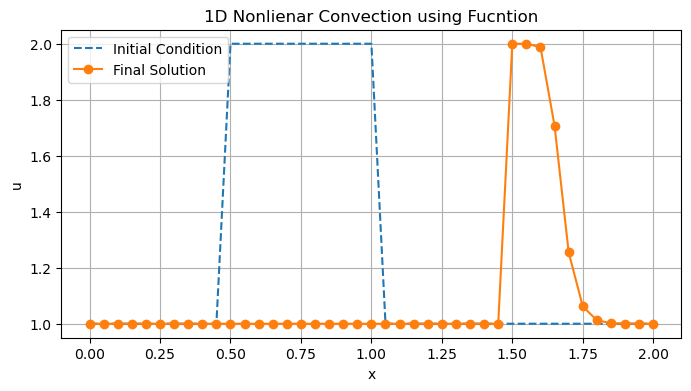

In [2]:
# using the function 

x, u_initial, u_final, cfl = solve_nonlinear_convection(nx = 41, nt = 20, dt = 0.025, length = 2.0)

print("CFL number:", cfl)

plt.figure(figsize=(8,4))
plt.plot(x, u_initial, label = "Initial Condition", linestyle = "--")
plt.plot(x, u_final, label = "Final Solution", marker = "o")
plt.xlabel("x")
plt.ylabel("u")
plt.title("1D Nonlienar Convection using Fucntion")
plt.legend()
plt.grid()
plt.show()



In [3]:
# Compare linear and nonlienar convection

def solve_linear_convection(nx = 41, nt = 20, dt = 0.025, c = 1.0, length = 2.0):
    """
    Solve the 1D convection equation using an explicit upwind scheme

    Equation:
     du/dt + c du/dx = 0
    """ 

    dx = length / (nx - 1)
    x = np.linspace(0, length, nx)

    u_initial = np.ones(nx)
    u_initial[int(0.5 / dx):int(1.0 / dx + 1)] = 2

    u = u_initial.copy()

    for n in range(nt):
        un = u.copy()

        for i in range (1,nx):
            u[i] = un[i] - c *dt / dx * (un[i] - un[i -1])


    return x, u_initial, u 

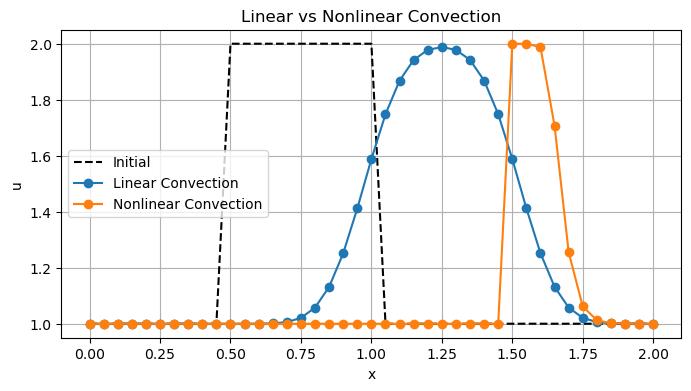

In [4]:
x , u_initial, u_linear = solve_linear_convection(nx = 41, nt = 20, dt = 0.025, length = 2.0)

x, u_initial, u_nonlinear, cfl = solve_nonlinear_convection(nx = 41, nt = 20, dt = 0.025, length = 2.0)

plt.figure(figsize = (8,4))
plt.plot(x, u_initial, "k--", label = "Initial")
plt.plot(x, u_linear, label = "Linear Convection", marker = "o")
plt.plot(x, u_nonlinear, label = "Nonlinear Convection", marker = "o")

plt.xlabel("x")
plt.ylabel("u")
plt.title("Linear vs Nonlinear Convection")
plt.legend()
plt.grid()
plt.show()

In this Notebook, I solved the 1D nonlinear convection equation: 

$$
\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} = 0
$$


Main concepts learned: 

- difference between linear and nonlinear convection 
- local wave speed
- explicit upwind discretization
- time marching 
- nonlinear deformation of the solution
- CFL condition for nonlinear convection
- comparison between linear and nonlinear flow transport

Engineering Interpretation:

In linear convection: all parts of the wave travel with the same speed 
In nonlinear convection: the wave speed depends on the solution itself. Therefore, larger values of \(u\) move faster and the wave shape changes over time.

This is an important foundation for understanding nonlinear behaviour in fluid mechanics, including wake distortion, vortex intreactio,, flow separation, and aerodynamic unstediness in aerospace and automotive applications.

For external aerodynamics, flow structures do not simply move like rigid shapes. They deform, stretch, rotate, merge, and dissipate.

Aircraft wing wake        → vortices convect and deform downstream
F1 rear wing wake         → high-energy and low-energy flow regions interact
Diffuser flow             → velocity gradients influence pressure recovery
Wheel wake                → rotating structures interact with freestream flow
Vortex generators         → induced vortices evolve nonlinearly

The nonlinear convection equation is not a full aerodynamic solver, but it teaches first numerical idea behind these phenomena:

The flow field transports itself

That is the core of the nonlinear term in the Navier-Stokes equations
